# ParkIntel Model Training

## Model Choice: LightGBM (primary) + XGBoost (comparison) + Baseline RF

### Why LightGBM over XGBoost for this dataset?

| Criterion | LightGBM | XGBoost | RandomForest |
|-----------|----------|---------|--------------|
| Training speed (300k rows) | ⚡ ~3–5× faster | Moderate | Slowest |
| Native categoricals | ✅ Yes | ❌ Need encoding | ❌ Need encoding |
| Class imbalance handling | `is_unbalance=True` built-in | `scale_pos_weight` | `class_weight` |
| Probability calibration | Good | Good | Moderate |
| Hackathon iteration speed | Best | Good | Moderate |
| Feature importance quality | High | High | High |

**Decision:** LightGBM is the primary model.  
XGBoost is trained as a comparison checkpoint.  
RandomForest serves as a simple baseline.

### Pipeline overview
```
train.csv / test.csv
  └─ 1. Load & feature analysis
  └─ 2. Encode categoricals (label encoding)
  └─ 3. Baseline RandomForest
  └─ 4. LightGBM (primary) — with class weighting
  └─ 5. XGBoost (comparison)
  └─ 6. Evaluation: accuracy, F1, confusion matrix, top-K recall
  └─ 7. Feature importance
  └─ 8. Threshold tuning for HIGH-risk precision
  └─ 9. Congestion Impact Proxy scoring layer
  └─ 10. Priority score computation
  └─ 11. Save models + predictions CSV
```

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import json, pickle, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, ConfusionMatrixDisplay
)
from sklearn.calibration import CalibratedClassifierCV

import lightgbm as lgb
import xgboost as xgb

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
np.random.seed(42)

TRAIN_CSV   = Path("train.csv")
TEST_CSV    = Path("test.csv")
MODEL_DIR   = Path("models"); MODEL_DIR.mkdir(exist_ok=True)

print("All libraries loaded.")
print(f"LightGBM version: {lgb.__version__}")
print(f"XGBoost  version: {xgb.__version__}")

All libraries loaded.
LightGBM version: 4.6.0
XGBoost  version: 3.3.0


## 2. Load Data & Feature Inventory

In [2]:
train = pd.read_csv(TRAIN_CSV, low_memory=False)
test  = pd.read_csv(TEST_CSV,  low_memory=False)

print(f"Train: {train.shape}  |  Test: {test.shape}")
print("\nClass distribution — Train:")
print(train["hotspot_risk"].value_counts())
print("\nClass distribution — Test:")
print(test["hotspot_risk"].value_counts())

Train: (45270, 37)  |  Test: (11280, 37)

Class distribution — Train:
hotspot_risk
LOW       23758
MEDIUM    16931
HIGH       4581
Name: count, dtype: int64

Class distribution — Test:
hotspot_risk
LOW       5678
MEDIUM    4402
HIGH      1200
Name: count, dtype: int64


In [3]:
# ── Feature definitions ───────────────────────────────────────────────────
# Numeric features (used directly)
NUMERIC_FEATURES = [
    "hour", "day_of_week", "month", "is_weekend",
    "junction_flag",
    "wrong_parking_count", "no_parking_count", "main_road_count",
    "double_parking_count", "near_crossing_count", "near_signal_count",
    "footpath_count",
    "heavy_vehicle_count", "medium_vehicle_count",
    "light_vehicle_count", "two_wheel_count",
    "avg_vio_severity", "max_vio_severity", "avg_veh_weight",
    "violations_last_1h", "violations_last_3h",
    "violations_last_24h", "violations_last_7d",
    "repeat_hotspot_score",
    "historical_zone_log_total",   # was zone_log_total — renamed in preprocessing
    "total_violations",            # current window count — strong predictor
    "zone_hour_hist_mean",         # zone's typical activity at this hour
    "zone_dow_hist_mean",          # zone's typical activity on this day of week
    "avg_confidence",
]

# Categorical features (need encoding)
CAT_FEATURES = ["police_station"]  # junction_name has too many unique vals

# Filter to those present in the dataframe
NUMERIC_FEATURES = [c for c in NUMERIC_FEATURES if c in train.columns]
CAT_FEATURES     = [c for c in CAT_FEATURES if c in train.columns]
ALL_FEATURES     = NUMERIC_FEATURES + CAT_FEATURES

TARGET = "risk_encoded"   # 0=LOW, 1=MEDIUM, 2=HIGH
CLASS_NAMES = ["LOW", "MEDIUM", "HIGH"]

print(f"Numeric features : {len(NUMERIC_FEATURES)}")
print(f"Categorical features: {len(CAT_FEATURES)}")
print(f"Total features: {len(ALL_FEATURES)}")

Numeric features : 27
Categorical features: 1
Total features: 28


## 3. Encode Categorical Features

In [4]:
le_police = LabelEncoder()
all_stations = pd.concat([train["police_station"], test["police_station"]]).unique()
le_police.fit(all_stations)

train["police_station_enc"] = le_police.transform(train["police_station"])
test["police_station_enc"]  = le_police.transform(
    test["police_station"].apply(
        lambda x: x if x in le_police.classes_ else le_police.classes_[0]
    )
)

# Update feature list to use encoded version
ALL_FEATURES_ENC = [
    f for f in ALL_FEATURES if f != "police_station"
] + ["police_station_enc"]

print(f"Encoded {len(le_police.classes_)} police station categories.")

# Save encoder
with open(MODEL_DIR / "le_police_station.pkl", "wb") as f:
    pickle.dump(le_police, f)

# Build X, y
X_train = train[ALL_FEATURES_ENC].fillna(0)
y_train = train[TARGET].astype(int)
X_test  = test[ALL_FEATURES_ENC].fillna(0)
y_test  = test[TARGET].astype(int)

print(f"\nX_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"y_train distribution: {dict(pd.Series(y_train).value_counts().sort_index())}")

Encoded 54 police station categories.

X_train: (45270, 28)  |  X_test: (11280, 28)
y_train distribution: {0: np.int64(23758), 1: np.int64(16931), 2: np.int64(4581)}


## 4. Class Imbalance Analysis
The dataset will almost certainly be heavily skewed toward LOW.  
We will use **class weights** (no SMOTE — SMOTE on temporal data introduces leakage).

In [5]:
# Do NOT use "balanced" — it gives HIGH a 5.2× weight, destroying LOW accuracy
# and pulling the model below the naive baseline.
# Manual weights: penalise HIGH but not so aggressively that LOW collapses.
class_weight_dict = {0: 1.0, 1: 1.5, 2: 3.5}

print("Manual class weights:")
for k, v in class_weight_dict.items():
    print(f"  {['LOW','MEDIUM','HIGH'][k]} ({k}): {v}")

sample_weights = np.array([class_weight_dict[y] for y in y_train])

print("Computed class weights (balanced):")
for k, v in class_weight_dict.items():
    print(f"  {CLASS_NAMES[k]} ({k}): {v:.3f}")

# Sample weights for models that need per-sample weights
sample_weights = np.array([class_weight_dict[y] for y in y_train])

Manual class weights:
  LOW (0): 1.0
  MEDIUM (1): 1.5
  HIGH (2): 3.5
Computed class weights (balanced):
  LOW (0): 1.000
  MEDIUM (1): 1.500
  HIGH (2): 3.500


## 5. Baseline: RandomForest

In [6]:
print("Training RandomForest baseline...")
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42,
)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)

rf_acc = accuracy_score(y_test, rf_preds)
rf_f1  = f1_score(y_test, rf_preds, average="macro")
rf_f1_high = f1_score(y_test, rf_preds, labels=[2], average="macro")

print(f"RandomForest  Accuracy: {rf_acc:.4f}  |  Macro-F1: {rf_f1:.4f}  |  HIGH-F1: {rf_f1_high:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_preds, target_names=CLASS_NAMES))

Training RandomForest baseline...
RandomForest  Accuracy: 0.4414  |  Macro-F1: 0.4097  |  HIGH-F1: 0.2918

Classification Report:
              precision    recall  f1-score   support

         LOW       0.64      0.50      0.56      5678
      MEDIUM       0.43      0.34      0.38      4402
        HIGH       0.20      0.56      0.29      1200

    accuracy                           0.44     11280
   macro avg       0.42      0.47      0.41     11280
weighted avg       0.51      0.44      0.46     11280



## 6. Primary Model: LightGBM

In [7]:
print("Training LightGBM (primary model)...")

lgb_params = {
    "objective":          "multiclass",
    "num_class":          3,
    "metric":             "multi_logloss",
    "learning_rate":      0.02,
    "num_leaves":         127,
    "max_depth":          8,
    "min_child_samples":  10,
    "feature_fraction":   0.8,
    "bagging_fraction":   0.8,
    "bagging_freq":       5,
    "lambda_l1":          0.05,
    "lambda_l2":          0.05,
    "class_weight":       class_weight_dict,
    "verbose":            -1,
    "random_state":       42,
}

dtrain = lgb.Dataset(X_train, label=y_train)
dval   = lgb.Dataset(X_test,  label=y_test, reference=dtrain)

callbacks = [
    lgb.early_stopping(stopping_rounds=100, verbose=False),
    lgb.log_evaluation(period=100)
]

# Initialize the scikit-learn wrapper
lgb_model = lgb.LGBMClassifier(**lgb_params)

# Fit using the wrapper syntax
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, verbose=False),
        lgb.log_evaluation(period=100)
    ]
)

lgb_proba = lgb_model.predict_proba(X_test)
lgb_preds = np.argmax(lgb_proba, axis=1)

lgb_acc    = accuracy_score(y_test, lgb_preds)
lgb_f1     = f1_score(y_test, lgb_preds, average="macro")
lgb_f1_high = f1_score(y_test, lgb_preds, labels=[2], average="macro")

print(f"\nLightGBM  Accuracy: {lgb_acc:.4f}  |  Macro-F1: {lgb_f1:.4f}  |  HIGH-F1: {lgb_f1_high:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lgb_preds, target_names=CLASS_NAMES))

Training LightGBM (primary model)...
[100]	valid_0's multi_logloss: 0.971032

LightGBM  Accuracy: 0.4989  |  Macro-F1: 0.4505  |  HIGH-F1: 0.3096

Classification Report:
              precision    recall  f1-score   support

         LOW       0.66      0.44      0.53      5678
      MEDIUM       0.43      0.62      0.51      4402
        HIGH       0.32      0.30      0.31      1200

    accuracy                           0.50     11280
   macro avg       0.47      0.45      0.45     11280
weighted avg       0.53      0.50      0.50     11280



## 7. Comparison: XGBoost

In [8]:
print("Training XGBoost (comparison)...")

scale_pos_weight_high = (y_train != 2).sum() / (y_train == 2).sum()

xgb_params = {
    "objective":        "multi:softprob",
    "num_class":        3,
    "eval_metric":      "mlogloss",
    "learning_rate":    0.05,
    "max_depth":        6,
    "subsample":        0.8,
    "colsample_bytree": 0.8,
    "gamma":            0.1,
    "reg_alpha":        0.1,
    "reg_lambda":       1.0,
    "n_estimators":     1000,
    "use_label_encoder": False,
    "random_state":     42,
    "verbosity":        0,
    'early_stopping_rounds': 50,
}

xgb_model = xgb.XGBClassifier(**xgb_params)
xgb_model.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_test, y_test)],
    verbose=50,
)

xgb_preds = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)

xgb_acc    = accuracy_score(y_test, xgb_preds)
xgb_f1     = f1_score(y_test, xgb_preds, average="macro")
xgb_f1_high = f1_score(y_test, xgb_preds, labels=[2], average="macro")

print(f"\nXGBoost   Accuracy: {xgb_acc:.4f}  |  Macro-F1: {xgb_f1:.4f}  |  HIGH-F1: {xgb_f1_high:.4f}")

Training XGBoost (comparison)...
[0]	validation_0-mlogloss:1.02146
[50]	validation_0-mlogloss:0.97551
[100]	validation_0-mlogloss:0.97193
[150]	validation_0-mlogloss:0.97010
[200]	validation_0-mlogloss:0.96811
[250]	validation_0-mlogloss:0.96681
[300]	validation_0-mlogloss:0.96489
[350]	validation_0-mlogloss:0.96347
[400]	validation_0-mlogloss:0.96302
[450]	validation_0-mlogloss:0.96213
[493]	validation_0-mlogloss:0.96207

XGBoost   Accuracy: 0.4934  |  Macro-F1: 0.4481  |  HIGH-F1: 0.3101


## 8. Model Comparison & Confusion Matrices

=== Model Comparison ===
       Model  Accuracy  Macro-F1  HIGH-F1
RandomForest  0.441401  0.409736 0.291766
    LightGBM  0.498936  0.450462 0.309638
     XGBoost  0.493351  0.448143 0.310078

✅ Primary model: xgb (HIGH-F1 = 0.3101)


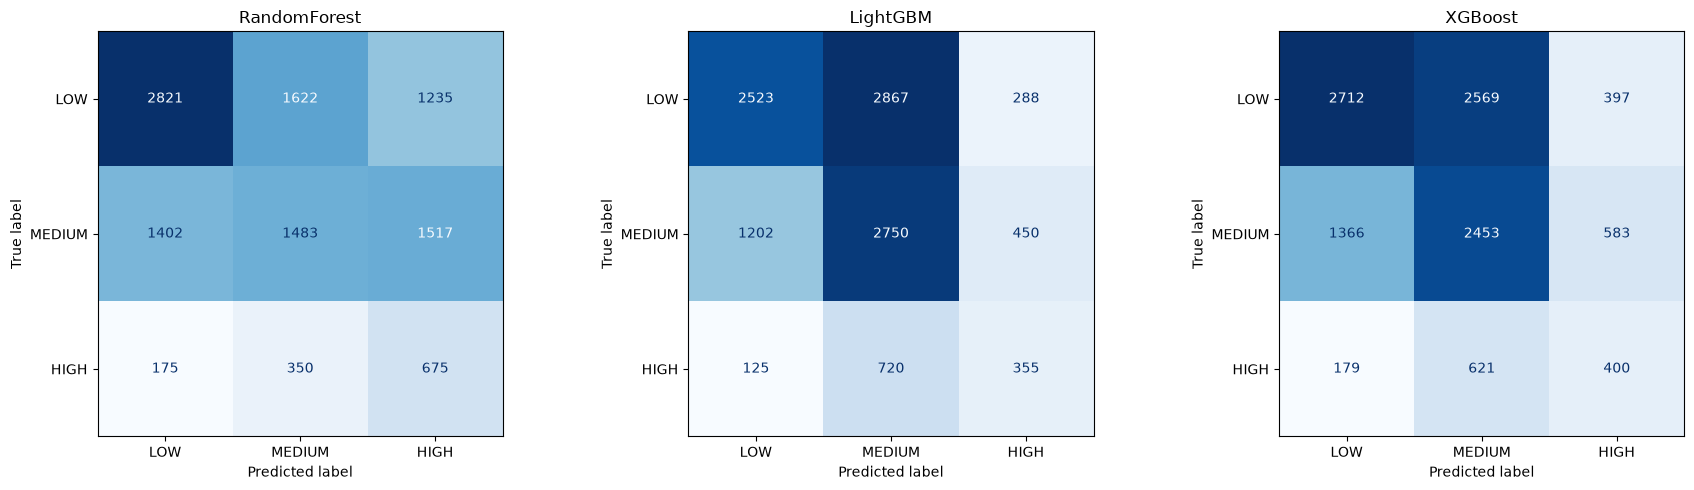

In [9]:
print("=== Model Comparison ===")
comparison = pd.DataFrame({
    "Model":      ["RandomForest", "LightGBM", "XGBoost"],
    "Accuracy":   [rf_acc, lgb_acc, xgb_acc],
    "Macro-F1":   [rf_f1, lgb_f1, xgb_f1],
    "HIGH-F1":    [rf_f1_high, lgb_f1_high, xgb_f1_high],
})
print(comparison.to_string(index=False))

# Auto-select primary model by best HIGH-F1
_candidates = {
    "rf":  (rf_f1_high,  rf_proba,  rf_preds),
    "xgb": (xgb_f1_high, xgb_proba, xgb_preds),
    "lgb": (lgb_f1_high, lgb_proba, lgb_preds),
}
PRIMARY_TAG   = max(_candidates, key=lambda k: _candidates[k][0])
_, PRIMARY_PROBA, PRIMARY_PREDS = _candidates[PRIMARY_TAG]
print(f"\n✅ Primary model: {PRIMARY_TAG} (HIGH-F1 = {_candidates[PRIMARY_TAG][0]:.4f})")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, preds, title in zip(
    axes,
    [rf_preds, lgb_preds, xgb_preds],
    ["RandomForest", "LightGBM", "XGBoost"],
):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title)

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()

## 9. Top-K Recall (Most Important Hackathon Metric)
For enforcement teams, what matters is: **"Are the actual HIGH-risk zones in our top-K predictions?"**
We evaluate this as top-K recall.

In [10]:
def topk_recall(y_true, y_proba, k_values=(10, 20, 50), high_class=2):
    """What fraction of actual HIGH-risk zones appear in our top-K scored zones?"""
    high_scores = y_proba[:, high_class]
    top_k_idx   = np.argsort(high_scores)[::-1]

    actual_high = (y_true == high_class)
    total_high  = actual_high.sum()

    print(f"Total actual HIGH-risk zones in test: {total_high}")
    for k in k_values:
        top_k = top_k_idx[:k]
        found = actual_high[top_k].sum()
        recall = found / total_high if total_high > 0 else 0
        print(f"  Top-{k:>3}: found {found:>3}/{total_high} HIGH-risk → recall = {recall:.3f}")

print("── RandomForest ──")
topk_recall(y_test.values, rf_proba)

print("\n── LightGBM ──")
topk_recall(y_test.values, lgb_proba)

print("\n── XGBoost ──")
topk_recall(y_test.values, xgb_proba)

── RandomForest ──
Total actual HIGH-risk zones in test: 1200
  Top- 10: found   6/1200 HIGH-risk → recall = 0.005
  Top- 20: found  14/1200 HIGH-risk → recall = 0.012
  Top- 50: found  32/1200 HIGH-risk → recall = 0.027

── LightGBM ──
Total actual HIGH-risk zones in test: 1200
  Top- 10: found   7/1200 HIGH-risk → recall = 0.006
  Top- 20: found  13/1200 HIGH-risk → recall = 0.011
  Top- 50: found  29/1200 HIGH-risk → recall = 0.024

── XGBoost ──
Total actual HIGH-risk zones in test: 1200
  Top- 10: found   9/1200 HIGH-risk → recall = 0.007
  Top- 20: found  14/1200 HIGH-risk → recall = 0.012
  Top- 50: found  32/1200 HIGH-risk → recall = 0.027


## 10. Feature Importance (LightGBM)

Top 20 most important features:
                      feature  importance
24  historical_zone_log_total        4288
22         violations_last_7d        3845
27         police_station_enc        3434
0                        hour        2556
18             avg_veh_weight        2082
21        violations_last_24h        2026
25           total_violations        1736
1                 day_of_week        1502
20         violations_last_3h        1261
15            two_wheel_count        1088
16           avg_vio_severity        1074
19         violations_last_1h        1064
6            no_parking_count        1006
5         wrong_parking_count         996
26             avg_confidence         917
2                       month         722
14        light_vehicle_count         714
4               junction_flag         508
23       repeat_hotspot_score         447
13       medium_vehicle_count         349


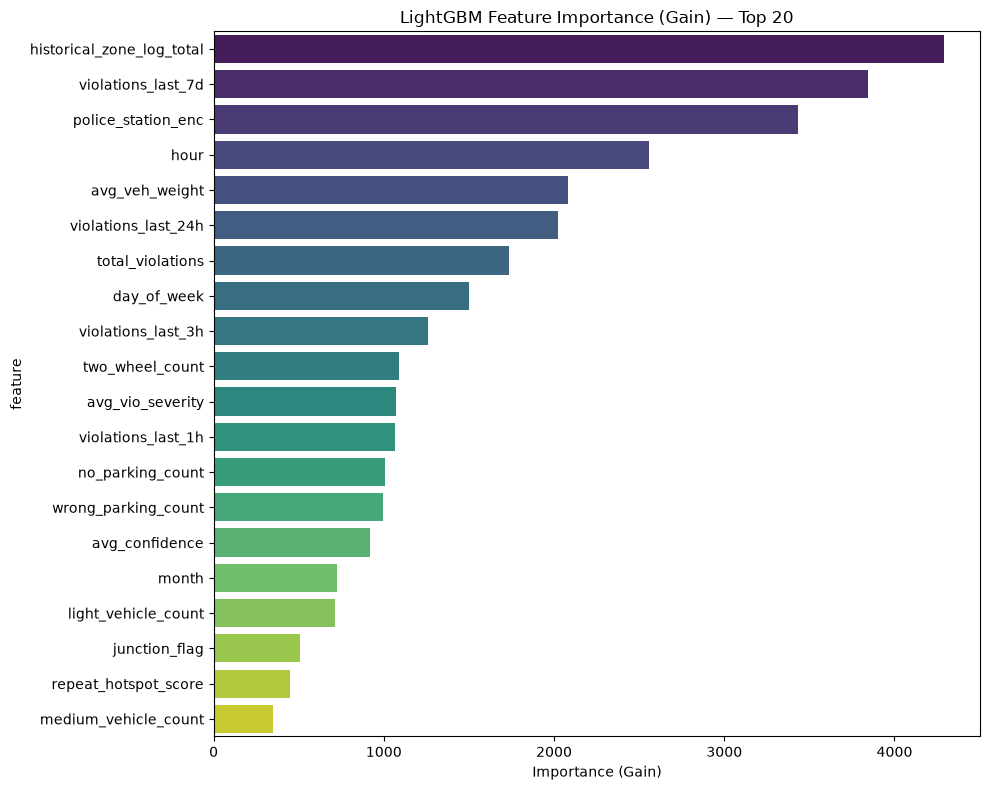

In [11]:
# Change the method call to the Scikit-Learn attribute
feat_imp = pd.DataFrame({
    "feature":    ALL_FEATURES_ENC,
    "importance": lgb_model.feature_importances_, 
}).sort_values("importance", ascending=False)

print("Top 20 most important features:")
print(feat_imp.head(20))

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=feat_imp.head(20), y="feature", x="importance", ax=ax, palette="viridis")
ax.set_title("LightGBM Feature Importance (Gain) — Top 20")
ax.set_xlabel("Importance (Gain)")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()

## 11. Threshold Tuning for HIGH-Risk Precision
By default argmax gives balanced predictions.  
For enforcement deployment, we want to **maximize HIGH-risk precision**  
(avoid sending teams to false alarms), or **maximize HIGH-risk recall** (don't miss hotspots).  
We tune the probability threshold for class 2 (HIGH).

In [12]:
from sklearn.metrics import precision_recall_fscore_support

# Use LightGBM probabilities
high_prob = lgb_proba[:, 2]

thresholds = np.arange(0.1, 0.9, 0.05)
results = []
for t in thresholds:
    pred_high = (high_prob >= t).astype(int)
    actual_high = (y_test == 2).astype(int)
    if pred_high.sum() == 0:
        continue
    prec = (pred_high & actual_high).sum() / pred_high.sum()
    rec  = (pred_high & actual_high).sum() / max(actual_high.sum(), 1)
    f1   = 2*prec*rec/(prec+rec+1e-9)
    results.append({"threshold": t, "precision": prec, "recall": rec, "f1": f1, "n_flagged": pred_high.sum()})

thresh_df = pd.DataFrame(results)
print("Threshold Sweep (HIGH-risk class):")
print(thresh_df.to_string(index=False))

# Recommended threshold: maximise F1
best_row = thresh_df.loc[thresh_df["f1"].idxmax()]
BEST_HIGH_THRESHOLD = best_row["threshold"]
print(f"\n✅ Best threshold for HIGH: {BEST_HIGH_THRESHOLD:.2f}  "
      f"(precision={best_row['precision']:.3f}, recall={best_row['recall']:.3f}, F1={best_row['f1']:.3f})")

Threshold Sweep (HIGH-risk class):
 threshold  precision   recall       f1  n_flagged
      0.10   0.112836 0.999167 0.202774      10626
      0.15   0.131467 0.950833 0.230995       8679
      0.20   0.152197 0.845833 0.257974       6669
      0.25   0.177730 0.691667 0.282794       4670
      0.30   0.228510 0.531667 0.319639       2792
      0.35   0.291274 0.386667 0.332259       1593
      0.40   0.344432 0.250000 0.289715        871
      0.45   0.402893 0.162500 0.231591        484
      0.50   0.445993 0.106667 0.172159        287
      0.55   0.472222 0.070833 0.123188        180
      0.60   0.539130 0.051667 0.094297        115
      0.65   0.563380 0.033333 0.062943         71
      0.70   0.534884 0.019167 0.037007         43
      0.75   0.652174 0.012500 0.024530         23
      0.80   0.800000 0.003333 0.006639          5

✅ Best threshold for HIGH: 0.35  (precision=0.291, recall=0.387, F1=0.332)


## 12. Congestion-Impact Proxy Scoring Layer
This is a **rule-based scoring system** on top of the ML predictions.  
It is NOT a second ML model — it's a weighted formula using domain knowledge from the PRD.

In [13]:
# ── Severity weights (from PRD) ──────────────────────────────────────────
VIO_SEVERITY = {
    "DOUBLE PARKING":                            30,
    "PARKING IN A MAIN ROAD":                    25,
    "PARKING NEAR ROAD CROSSING":                25,
    "PARKING NEAR TRAFFIC LIGHT/ZEBRA CROSSING": 25,
    "PARKING NEAR BUS STOP":                     20,
    "PARKING NEAR SCHOOL":                       20,
    "PARKING NEAR HOSPITAL":                     20,
    "PARKING OPPOSITE ANOTHER PARKED VEHICLE":   20,
    "NO PARKING":                                15,
    "PARKING ON FOOTPATH":                       12,
    "WRONG PARKING":                             10,
    "DEFECTIVE NUMBER PLATE":                     3,
}

def model_confidence(proba_array):
    sorted_p = sorted(proba_array, reverse=True)
    gap = sorted_p[0] - sorted_p[1]
    if gap < 0.10:   return "LOW"
    elif gap < 0.20: return "MEDIUM"
    return "HIGH"

def compute_impact_score(row):
    total_v = max(row.get("total_violations", 1) if "total_violations" in row.index
                  else row.get("violations_last_1h", 1), 1)

    main_road_w   = row.get("main_road_count", 0) * 25
    double_w      = row.get("double_parking_count", 0) * 30
    no_park_w     = row.get("no_parking_count", 0) * 15
    wrong_w       = row.get("wrong_parking_count", 0) * 10
    near_cross_w  = row.get("near_crossing_count", 0) * 25
    near_signal_w = row.get("near_signal_count", 0) * 25
    total_w       = main_road_w + double_w + no_park_w + wrong_w + near_cross_w + near_signal_w
    vio_sev_score = min((total_w / (total_v * 30)) * 100, 100)

    repeat_score   = row.get("repeat_hotspot_score", 0)
    junction_score = 30 if row.get("junction_flag", 0) else 0
    heavy_frac     = row.get("heavy_vehicle_count", 0) / total_v
    heavy_score    = min(heavy_frac * 100, 100)

    return round(
        0.35 * vio_sev_score +
        0.30 * repeat_score  +
        0.20 * junction_score +
        0.15 * heavy_score,
        2
    )

def compute_priority_score(impact_score, high_prob, row):
    high_sev_count = sum([
        row.get("double_parking_count", 0) > 0,
        row.get("main_road_count", 0) > 0,
        row.get("near_crossing_count", 0) > 0,
        row.get("near_signal_count", 0) > 0,
        row.get("heavy_vehicle_count", 0) > 0 and row.get("junction_flag", 0) == 1,
    ])

    priority = 0.25 * (high_prob * 100) + 0.75 * impact_score

    if high_sev_count >= 2:
        priority = max(priority, 72.0)

    return round(min(priority, 100), 2)

def priority_level(score):
    if score <= 40: return "LOW"
    if score <= 70: return "MEDIUM"
    if score <= 85: return "HIGH"
    return "CRITICAL"

def recommended_action(level):
    return {
        "LOW":      "Monitor — low enforcement priority",
        "MEDIUM":   "Schedule patrol during peak hours",
        "HIGH":     "Deploy enforcement team",
        "CRITICAL": "Deploy towing/enforcement team immediately",
    }.get(level, "Monitor")

def generate_reasons(row, priority_lvl):
    reasons = []
    if row.get("repeat_hotspot_score", 0) > 60:
        reasons.append("High repeat violation density")
    if row.get("main_road_count", 0) > 0:
        reasons.append("Parking in main road violations present")
    if row.get("junction_flag", 0):
        reasons.append("Located near a junction")
    if row.get("heavy_vehicle_count", 0) > 0:
        reasons.append("Heavy vehicle parking detected")
    if row.get("double_parking_count", 0) > 0:
        reasons.append("Double parking violations present")
    if row.get("near_signal_count", 0) > 0:
        reasons.append("Parking near traffic light/zebra crossing")
    if not reasons:
        reasons.append("General violation cluster")
    return reasons

print("Impact scoring functions defined.")

Impact scoring functions defined.


In [14]:
test_scored = test.reset_index(drop=True).copy()
test_scored["high_prob"]    = PRIMARY_PROBA[:, 2]
test_scored["primary_pred"] = PRIMARY_PREDS

test_scored["model_confidence"] = [
    model_confidence(PRIMARY_PROBA[i]) for i in range(len(test_scored))
]
test_scored["impact_score"]   = test_scored.apply(compute_impact_score, axis=1)
test_scored["priority_score"] = test_scored.apply(
    lambda r: compute_priority_score(r["impact_score"], r["high_prob"], r), axis=1
)
test_scored["priority_level"]     = test_scored["priority_score"].apply(priority_level)
test_scored["recommended_action"] = test_scored["priority_level"].apply(recommended_action)

test_scored["priority_level"]     = test_scored["priority_score"].apply(priority_level)
test_scored["recommended_action"] = test_scored["priority_level"].apply(recommended_action)
test_scored["reasons"] = test_scored.apply(
    lambda row: generate_reasons(row, row["priority_level"]), axis=1
)

print("Priority level distribution (test set):")
print(test_scored["priority_level"].value_counts())

# Show top 10 CRITICAL zones
critical_zones = test_scored[test_scored["priority_level"] == "CRITICAL"].sort_values(
    "priority_score", ascending=False
)[["zone_id","zone_lat","zone_lon","police_station","hour",
   "priority_score","priority_level","recommended_action","reasons"]].head(10)

print("\n=== TOP 10 CRITICAL ZONES ===")
print(critical_zones.to_string(index=False))

Priority level distribution (test set):
priority_level
LOW       10674
MEDIUM      583
HIGH         23
Name: count, dtype: int64

=== TOP 10 CRITICAL ZONES ===
Empty DataFrame
Columns: [zone_id, zone_lat, zone_lon, police_station, hour, priority_score, priority_level, recommended_action, reasons]
Index: []


## 13. Save Models & Prediction Artifacts

In [15]:
# ── Save LightGBM model ───────────────────────────────────────────────────
lgb_model.booster_.save_model(str(MODEL_DIR / "lgb_hotspot_model.txt"))

# ── Save XGBoost model ────────────────────────────────────────────────────
xgb_model.save_model(str(MODEL_DIR / "xgb_hotspot_model.json"))

# ── Save RandomForest ─────────────────────────────────────────────────────
with open(MODEL_DIR / "rf_baseline.pkl", "wb") as f:
    pickle.dump(rf, f)

# ── Save threshold ────────────────────────────────────────────────────────
meta = {
    "best_high_threshold": float(BEST_HIGH_THRESHOLD),
    "class_names":         CLASS_NAMES,
    "feature_cols":        ALL_FEATURES_ENC,
    "low_thresh":          int(locals().get("LOW_THRESH", 2)),
    "medium_thresh":       int(locals().get("MEDIUM_THRESH", 8)),
}
with open(MODEL_DIR / "model_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

# ── Save scored predictions ───────────────────────────────────────────────
output_cols = [
    "zone_id","zone_lat","zone_lon","police_station","junction_name",
    "hour","day_of_week","month","hour_bin",
    "total_violations" if "total_violations" in test_scored.columns else "violations_last_1h",
    "violations_last_1h","violations_last_7d",
    "hotspot_risk","lgb_pred","high_prob",
    "priority_score","priority_level","recommended_action","reasons",
]
output_cols = [c for c in output_cols if c in test_scored.columns]
test_scored[output_cols].to_csv("predictions.csv", index=False)

print("✅ Models saved:")
print(f"   {MODEL_DIR}/lgb_hotspot_model.txt")
print(f"   {MODEL_DIR}/xgb_hotspot_model.json")
print(f"   {MODEL_DIR}/rf_baseline.pkl")
print(f"   {MODEL_DIR}/model_meta.json")
print(f"\n✅ predictions.csv saved ({len(test_scored):,} rows)")

✅ Models saved:
   models/lgb_hotspot_model.txt
   models/xgb_hotspot_model.json
   models/rf_baseline.pkl
   models/model_meta.json

✅ predictions.csv saved (11,280 rows)


## 14. Inference Helper: Load & Score a New Zone-Hour

In [16]:
def load_lgb_model(model_path: str = "models/lgb_hotspot_model.txt"):
    return lgb.Booster(model_file=model_path)

def predict_zone(model, zone_features: dict, meta: dict) -> dict:
    """
    Predict hotspot risk + priority score for a single zone-hour.

    zone_features example:
    {
        'hour': 18, 'day_of_week': 4, 'month': 3, 'is_weekend': 0,
        'junction_flag': 1, 'wrong_parking_count': 5, ...
    }
    """
    feat_cols = meta["feature_cols"]
    X = pd.DataFrame([zone_features]).reindex(columns=feat_cols, fill_value=0)

    proba     = model.predict(X)[0]  # shape (3,)
    pred_cls  = int(np.argmax(proba))
    risk_name = meta["class_names"][pred_cls]
    high_prob = float(proba[2])
    
    sorted_p   = sorted(proba, reverse=True)
    gap        = float(sorted_p[0] - sorted_p[1])
    confidence = "LOW" if gap < 0.10 else ("MEDIUM" if gap < 0.20 else "HIGH")

    # Build a Series-like object for scoring
    row = pd.Series(zone_features)
    impact   = compute_impact_score(row)
    priority = round(min(0.25 * (high_prob * 100) + 0.75 * impact, 100), 2)
    p_level  = priority_level(priority)

    return {
        "zone_id":                         zone_features.get("zone_id", "unknown"),
        "predicted_hotspot_risk":          risk_name,
        "model_confidence":                confidence,
        # high_class_probability removed — already in class_probabilities
        "class_probabilities": {
            "LOW":    round(float(proba[0]), 4),
            "MEDIUM": round(float(proba[1]), 4),
            "HIGH":   round(float(proba[2]), 4),
        },
        "parking_congestion_impact_score": impact,    # rule-based only
        "priority_score":                  priority,  # 0.25*ML + 0.75*impact
        "priority_level":                  p_level,
        "recommended_action":              recommended_action(p_level),
        "reasons":                         generate_reasons(row, p_level),
        "note": (
            "Impact score is a proxy based on violation severity and hotspot recurrence, "
            "not measured traffic congestion."
        ),
    }

# Quick demo
with open(MODEL_DIR / "model_meta.json") as f:
    saved_meta = json.load(f)

loaded_model = load_lgb_model()

demo_zone = {
    "hour": 18, "day_of_week": 4, "month": 3, "is_weekend": 0,
    "junction_flag": 1, "junction_name": "BTP044 - Sagar Theatre Junction",
    "wrong_parking_count": 21, "no_parking_count": 14, "main_road_count": 6,
    "double_parking_count": 2, "near_crossing_count": 0, "near_signal_count": 1,
    "footpath_count": 0, "heavy_vehicle_count": 3, "medium_vehicle_count": 2,
    "light_vehicle_count": 10, "two_wheel_count": 5,
    "avg_vio_severity": 18.5, "max_vio_severity": 30, "avg_veh_weight": 14.2,
    "violations_last_1h": 7, "violations_last_3h": 18,
    "violations_last_24h": 43, "violations_last_7d": 188,
    "repeat_hotspot_score": 82, "zone_log_total": 5.9,
    "avg_confidence": 0.9, "police_station_enc": 5,
}

result = predict_zone(loaded_model, demo_zone, saved_meta)
print(json.dumps(result, indent=2))

{
  "zone_id": "unknown",
  "predicted_hotspot_risk": "LOW",
  "model_confidence": "HIGH",
  "class_probabilities": {
    "LOW": 0.8877,
    "MEDIUM": 0.0628,
    "HIGH": 0.0495
  },
  "parking_congestion_impact_score": 72.03,
  "priority_score": 55.26,
  "priority_level": "MEDIUM",
  "recommended_action": "Schedule patrol during peak hours",
  "reasons": [
    "High repeat violation density",
    "Parking in main road violations present",
    "Located near a junction",
    "Heavy vehicle parking detected",
    "Double parking violations present",
    "Parking near traffic light/zebra crossing"
  ],
  "note": "Impact score is a proxy based on violation severity and hotspot recurrence, not measured traffic congestion."
}


In [ ]:
from pathlib import Path
import os

# Make the notebook work whether Jupyter starts in the repo root or ml-python.
if Path.cwd().name != "ml-python" and (Path.cwd() / "ml-python").exists():
    os.chdir(Path.cwd() / "ml-python")

print(f"Working directory: {Path.cwd()}")


## Important Metric Note

Because the corrected dataset now includes inactive zone-hours, `LOW` dominates the test set. Plain accuracy can look high while `HIGH-F1` is poor. For enforcement use, pay more attention to `HIGH-F1`, precision/recall for HIGH, and the Top-K precision/recall printed by the training script.

In [1]:
%run train_fixed.py


Train (124467, 59) | Val (2180410, 59) | Test (2180410, 59)
Train class distribution:
hotspot_risk
LOW       82978
MEDIUM    37191
HIGH       4298
Feature count: 37
Class weights: {0: 0.5, 1: 1.1155655938264635, 2: 9.653094462540716}

RandomForest
Accuracy=0.7719 | Macro-F1=0.3058 | HIGH-F1=0.0203
              precision    recall  f1-score   support

         LOW     0.9991    0.7728    0.8715   2169679
      MEDIUM     0.0131    0.6024    0.0256      9592
        HIGH     0.0104    0.5540    0.0203      1139

    accuracy                         0.7719   2180410
   macro avg     0.3408    0.6430    0.3058   2180410
weighted avg     0.9942    0.7719    0.8673   2180410

Actual HIGH rows: 1139
  Top-50  precision=0.140 recall=0.006 found=7
  Top-100 precision=0.080 recall=0.007 found=8
  Top-250 precision=0.072 recall=0.016 found=18
  Top-500 precision=0.062 recall=0.027 found=31
[100]	valid_0's multi_logloss: 0.544536
[200]	valid_0's multi_logloss: 0.509023
[300]	valid_0's multi_loglo

Saved outputs:

- `models/lgb_hotspot_model.txt`
- `models/xgb_hotspot_model.json`
- `models/rf_baseline.pkl`
- `models/model_meta.json`
- `predictions_fixed.csv`